In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "transaction_amount": np.random.randint(100, 50000, n),
    "transaction_frequency": np.random.randint(1, 20, n),
    "account_age_days": np.random.randint(30, 3000, n),
    "international": np.random.randint(0, 2, n),
    "failed_attempts": np.random.randint(0, 6, n)
})

data["fraud"] = (
    ((data["transaction_amount"] > 30000) &
     (data["failed_attempts"] >= 3)) |
    ((data["international"] == 1) &
     (data["transaction_frequency"] > 12))
).astype(int)

# Add some randomness
noise = np.random.choice(n, size=120, replace=False)
data.loc[noise, "fraud"] = 1 - data.loc[noise, "fraud"]

print(data.head())
print("\nDataset shape:", data.shape)
print("\nFraud counts:")
print(data["fraud"].value_counts())

   transaction_amount  transaction_frequency  account_age_days  international  \
0               15895                     19               169              0   
1                 960                     12              1454              0   
2               38258                     18              2979              1   
3               44832                      6               546              0   
4               11384                     18              2646              1   

   failed_attempts  fraud  
0                4      0  
1                0      0  
2                1      1  
3                2      0  
4                2      1  

Dataset shape: (2000, 6)

Fraud counts:
fraud
0    1269
1     731
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X = data.drop("fraud", axis=1)
y = data["fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)
rf_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Decision Tree Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))

Decision Tree Accuracy: 0.9175
Random Forest Accuracy: 0.925


In [3]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

                 Feature  Importance
1  transaction_frequency    0.283002
0     transaction_amount    0.274810
4        failed_attempts    0.230833
3          international    0.191608
2       account_age_days    0.019747


NameError: name 'plt' is not defined

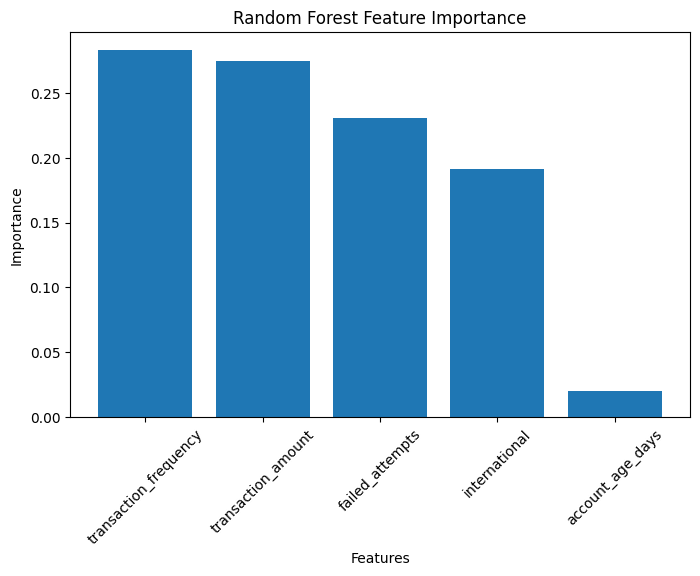

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Confusion Matrix:
[[240  14]
 [ 16 130]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       254
           1       0.90      0.89      0.90       146

    accuracy                           0.93       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.93      0.92       400



In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Accuracy Scores:")
print(scores)

print("\nMean Accuracy:", round(scores.mean(), 4))
print("Standard Deviation:", round(scores.std(), 4))

Cross-Validation Accuracy Scores:
[0.9225 0.94   0.955  0.9525 0.9275]

Mean Accuracy: 0.9395
Standard Deviation: 0.013


In [7]:
print("DAY 18 - FRAUD DETECTION USING RANDOM FOREST")
print("----------------------------------------------")
print("Dataset size:", data.shape)
print("Decision Tree Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Improvement:", round(
    accuracy_score(y_test, rf_pred) - accuracy_score(y_test, dt_pred), 4
))
print("Mean CV Accuracy:", round(scores.mean(), 4))
print("CV Standard Deviation:", round(scores.std(), 4))
print("Top Feature:", feature_importance.iloc[0]["Feature"])
print("Top Feature Importance:",
      round(feature_importance.iloc[0]["Importance"], 4))

DAY 18 - FRAUD DETECTION USING RANDOM FOREST
----------------------------------------------
Dataset size: (2000, 6)
Decision Tree Accuracy: 0.9175
Random Forest Accuracy: 0.925
Improvement: 0.0075
Mean CV Accuracy: 0.9395
CV Standard Deviation: 0.013
Top Feature: transaction_frequency
Top Feature Importance: 0.283


In [8]:
feature_importance.to_csv(
    "day18_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.
